Objetivo general

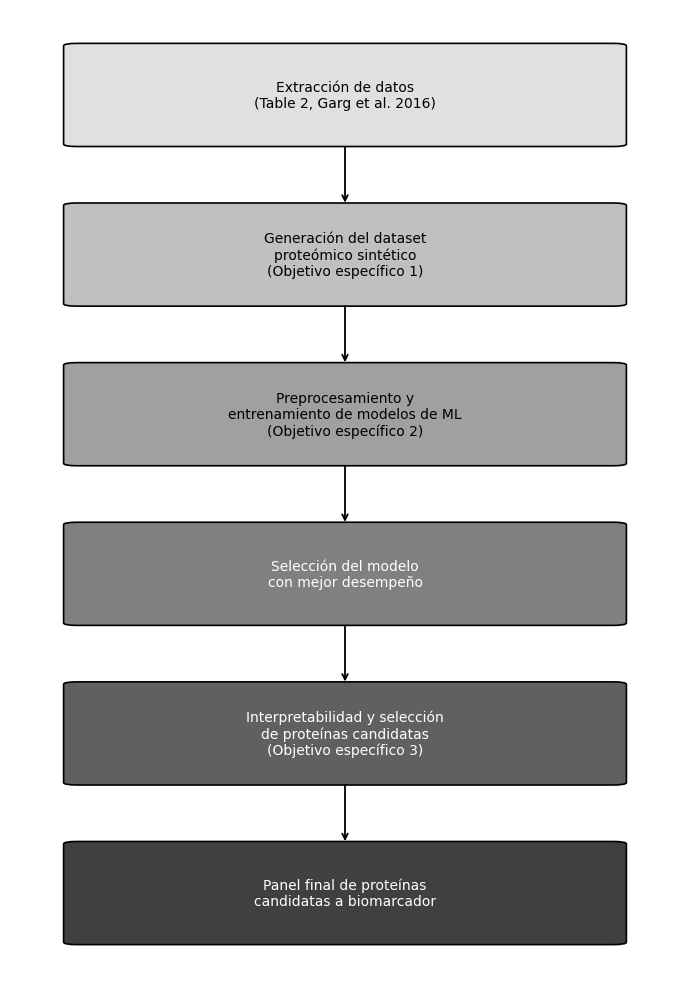

In [ ]:
# figura pipeline de trabajo para metodologia
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 10))

etapas = [
    ("Extracción de datos\n(Table 2, Garg et al. 2016)", "#e0e0e0"),
    ("Generación del dataset\nproteómico sintético\n(Objetivo específico 1)", "#c0c0c0"),
    ("Preprocesamiento y\nentrenamiento de modelos de ML\n(Objetivo específico 2)", "#a0a0a0"),
    ("Selección del modelo\ncon mejor desempeño", "#808080"),
    ("Interpretabilidad y selección\nde proteínas candidatas\n(Objetivo específico 3)", "#606060"),
    ("Panel final de proteínas\ncandidatas a biomarcador", "#404040"),
]

y_actual = len(etapas)
posiciones_y = []

for texto, color in etapas:
    y = y_actual
    posiciones_y.append(y)
    caja = patches.FancyBboxPatch(
        (0.1, y - 0.4), 0.8, 0.8,
        boxstyle="round,pad=0.02",
        edgecolor="black", facecolor=color, linewidth=1.2
    )
    ax.add_patch(caja)

    color_texto = "white" if color in ["#808080", "#606060", "#404040"] else "black"
    ax.text(0.5, y, texto, ha="center", va="center", fontsize=10, color=color_texto, wrap=True)
    y_actual -= 1.3

# Flechas entre etapas
for i in range(len(posiciones_y) - 1):
    ax.annotate("", xy=(0.5, posiciones_y[i+1] + 0.4), xytext=(0.5, posiciones_y[i] - 0.4),
                arrowprops=dict(arrowstyle="->", color="black", linewidth=1.3))

ax.set_xlim(0, 1)
ax.set_ylim(min(posiciones_y) - 0.7, max(posiciones_y) + 0.7)
ax.axis("off")

plt.tight_layout()
plt.savefig("figura_pipeline_general.png", dpi=200, bbox_inches="tight")
plt.show()

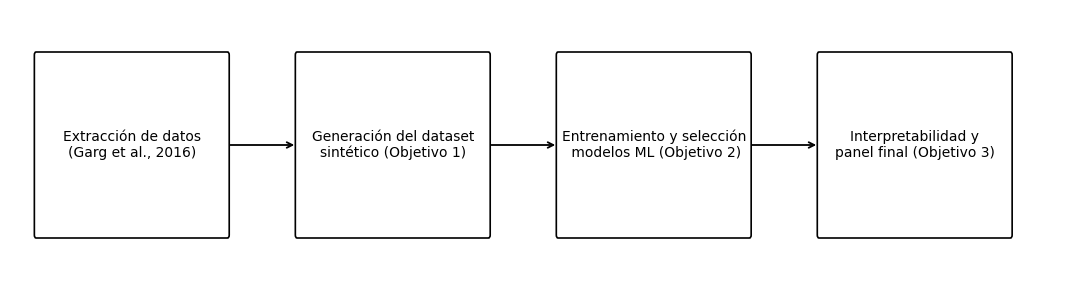

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 3))

etapas = [
    "Extracción de datos\n(Garg et al., 2016)",
    "Generación del dataset\nsintético (Objetivo 1)",
    "Entrenamiento y selección\n modelos ML (Objetivo 2)",
    "Interpretabilidad y\npanel final (Objetivo 3)"
]

x_actual = 0
posiciones_x = []
ancho_caja = 2.2
alto_caja = 1.2

for texto in etapas:
    x = x_actual
    posiciones_x.append(x)
    caja = patches.FancyBboxPatch(
        (x, 0), ancho_caja, alto_caja,
        boxstyle="round,pad=0.02",
        edgecolor="black", facecolor="white", linewidth=1.2
    )
    ax.add_patch(caja)
    ax.text(x + ancho_caja/2, alto_caja/2, texto, ha="center", va="center",
            fontsize=10, color="black")
    x_actual += ancho_caja + 0.8

# Flechas entre etapas
for i in range(len(posiciones_x) - 1):
    x_origen = posiciones_x[i] + ancho_caja
    x_destino = posiciones_x[i+1]
    ax.annotate("", xy=(x_destino, alto_caja/2), xytext=(x_origen, alto_caja/2),
                arrowprops=dict(arrowstyle="->", color="black", linewidth=1.3))

ax.set_xlim(-0.3, x_actual)
ax.set_ylim(-0.3, alto_caja + 0.3)
ax.axis("off")

plt.tight_layout()
plt.savefig("figura_pipeline_general.png", dpi=200, bbox_inches="tight")
plt.show()

**Objetivo especifico 1:** Generar un conjunto de datos proteómicos sintéticos capaces de simular la complejidad y las características del proteoma de las muestras clínicas humanas de pacientes con la finalidad de proporcionar un conjunto de datos adecuado para el entrenamiento y la evaluación de los modelos de ML.

**Extracción de datos del paper fuente.** Los datos originales para realizar la simulación se obtuvieron a partir del trabajo citado a continuación: Garg NJ, Soman KV, Zago MP, Koo S-J, Spratt H, Stafford S, et al. (2016) Changes in Proteome Profile of Peripheral Blood Mononuclear Cells in Chronic Chagas Disease. PLoS Negl Trop Dis 10(2): e0004490. doi:10.1371/journal. pntd.0004490.


In [ ]:
!apt-get install -y ghostscript -q
!pip install camelot-py[cv] -q

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 libgs9 libgs9-common
  libidn12 libijs-0.35 libjbig2dec0 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-ukai
  fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 poppler-data
0 upgraded, 10 newly installed, 0 to remove and 3 not upgraded.
Need to get 60.0 kB/16.7 MB of archives.
After this operation, 63.0 MB of additional disk space will be used.
Err:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libidn12 amd64 1.38-4ubuntu1
  404  Not Found [IP: 91.189

In [ ]:
import camelot
import pandas as pd
from google.colab import files
import os

In [ ]:
subida = files.upload()
paper = list(subida.keys())[0]

if os.path.exists(paper):
    print("pdf ok", paper)
else:
    print("error pdf")

Saving paper.pdf to paper (1).pdf
pdf ok paper (1).pdf


In [ ]:
paginas = "10-15"   # rango de paginas de la tabla 2 en el pdf

In [ ]:
tabla = camelot.read_pdf(paper, pages=paginas, flavor="stream") # cambie por stream xq lattice devolvia 0

print("Se encontraron", tabla.n, "partes de tabla en ese rango de páginas")

Se encontraron 7 partes de tabla en ese rango de páginas


/usr/local/lib/python3.12/dist-packages/camelot/parsers/base.py:302: UserWarning: No tables found in table area (190.01249999999996, 74.22437432000004, 578.9441892799999, 264.7347003)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


In [ ]:
# unir todas las partes de la tabla en 1 sola
partes = []
for parte in tabla:
    partes.append(parte.df)

datos = pd.concat(partes, ignore_index=True)
datos.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,PBMCs Proteomic Signature in Chagasic Patients,,,NaN
1,Table 2. Proteome profile of PBMC proteins in ...,,,,,,,,,,,NaN
2,Protein,Gene,Accession,Spot,pI,MW,Protein,E value,C/A-vs-N/H,C/S-vs-N/H,Localization,NaN
3,name,name,No.,No.,,(kDa),score,,,,,NaN
4,"Actin, alpha 1, skeletal",ACTA1,Q5T8M8,890,4.94,16,124,3.15E-08,2.63,2.49,CP,NaN
5,muscle,,,,,,,,,,,NaN
6,"Actin, alpha 1, skeletal",ACTA1,Q5T8M7,121,5.41,68,227,1.58E-18,-2.68,-2.63,CP,NaN
7,muscle,,,,,,,,,,,NaN
8,"Actin, cytoplasmic 1",ACTB,C9JUM1,769,5.38,14,44,3.15E+00,3.52,5.26,CP,NaN
9,,ACTB,C9JUM1,679,7.66,13,103,3.97E-06,2.42,2.61,CP,NaN


In [ ]:
filas, columnas = datos.shape
print(f"La tabla combinada tiene {filas} filas y {columnas} columnas.")

La tabla combinada tiene 305 filas y 12 columnas.


In [ ]:
datos.to_csv("tabla1.csv", index=False)
files.download("tabla1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabla de contingencia formato APA a partir de .csv Tabla1 post limpieza

In [ ]:
!pip install openpyxl -q

In [ ]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt

In [ ]:
subida = files.upload()
archivo = list(subida.keys())[0]

tabla = pd.read_excel(archivo)
tabla = tabla.dropna(how="all")  # saca la fila completamente vacía si existe

print("Archivo subido ok ✅ Filas:", tabla.shape[0], "Columnas:", tabla.shape[1])
tabla.head(10)

Saving tabla1.csv.xlsx to tabla1.csv (10).xlsx
Archivo subido ok ✅ Filas: 222 Columnas: 11


,Protein name,Gene name,Accession No.,Spot No.,pI,MW (kDa),Protein score,E value,C/A-vs-N/H,C/S-vs-N/H,Localization
0,"Actin, alpha 1, skeletal muscle",ACTA1,Q5T8M8,890,4.94,16,124,3.150000e-08,2.63,2.49,CP
1,"Actin, alpha 1, skeletal muscle",ACTA1,Q5T8M7,121,5.41,68,227,1.580000e-18,-2.68,-2.63,CP
2,"Actin, cytoplasmic 1",ACTB,C9JUM1,769,5.38,14,44,3.150000e+00,3.52,5.26,CP
3,NaN,ACTB,C9JUM1,679,7.66,13,103,3.970000e-06,2.42,2.61,CP
4,"Actin, cytoplasmic 1",ACTB,P60709,629,4.35,15,65,2.510000e-02,2.54,3.67,CP
5,NaN,NaN,NaN,303,4.54,38,91,6.290000e-05,-1.75,-1.78,NaN
6,NaN,NaN,NaN,657,4.79,15,108,1.260000e-06,4.55,4.91,NaN
7,NaN,NaN,NaN,642,4.21,15,139,9.980000e-10,2.28,2.73,NaN
8,NaN,NaN,NaN,621,4.59,16,153,3.970000e-11,2.63,2.77,NaN
9,NaN,NaN,NaN,896,4.29,14,198,1.260000e-15,7.99,8.88,NaN


In [ ]:
!pip install python-docx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
from docx import Document
from docx.shared import Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

documento = Document()

# --- Titulo tipo APA (numero en negrita, descripcion en cursiva debajo) ---
titulo = documento.add_paragraph()
titulo_run = titulo.add_run("Tabla 1")
titulo_run.bold = True
titulo_run.font.name = "Times New Roman"
titulo_run.font.size = Pt(12)

subtitulo = documento.add_paragraph()
subtitulo_run = subtitulo.add_run("Perfil proteómico diferencial en PBMC de pacientes con enfermedad de Chagas")
subtitulo_run.italic = True
subtitulo_run.font.name = "Times New Roman"
subtitulo_run.font.size = Pt(12)

# --- Creamos la tabla con las mismas columnas y filas del csv ---
columnas = list(tabla.columns)
filas = tabla.shape[0]

tabla_word = documento.add_table(rows=1, cols=len(columnas))

# Encabezado
celdas_encabezado = tabla_word.rows[0].cells
for i, nombre_columna in enumerate(columnas):
    celdas_encabezado[i].text = str(nombre_columna)
    for parrafo in celdas_encabezado[i].paragraphs:
        parrafo.alignment = WD_ALIGN_PARAGRAPH.CENTER
        for run in parrafo.runs:
            run.font.name = "Times New Roman"
            run.font.size = Pt(10)
            run.bold = True

# Filas con los datos (se completan tal cual estan en el csv)
for _, registro in tabla.iterrows():
    fila_nueva = tabla_word.add_row().cells
    for i, nombre_columna in enumerate(columnas):
        valor = registro[nombre_columna]
        fila_nueva[i].text = "" if pd.isna(valor) else str(valor)
        for parrafo in fila_nueva[i].paragraphs:
            parrafo.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for run in parrafo.runs:
                run.font.name = "Times New Roman"
                run.font.size = Pt(9)

# --- Formato APA: solo lineas horizontales (arriba y abajo), fondo blanco ---
def poner_borde_horizontal(fila_celdas, arriba=False, abajo=False):
    for celda in fila_celdas:
        tc_pr = celda._tc.get_or_add_tcPr()
        bordes = OxmlElement("w:tcBorders")
        if arriba:
            borde_arriba = OxmlElement("w:top")
            borde_arriba.set(qn("w:val"), "single")
            borde_arriba.set(qn("w:sz"), "8")
            borde_arriba.set(qn("w:color"), "000000")
            bordes.append(borde_arriba)
        if abajo:
            borde_abajo = OxmlElement("w:bottom")
            borde_abajo.set(qn("w:val"), "single")
            borde_abajo.set(qn("w:sz"), "8")
            borde_abajo.set(qn("w:color"), "000000")
            bordes.append(borde_abajo)
        tc_pr.append(bordes)

poner_borde_horizontal(tabla_word.rows[0].cells, arriba=True)
poner_borde_horizontal(tabla_word.rows[0].cells, abajo=True)
poner_borde_horizontal(tabla_word.rows[-1].cells, abajo=True)

# --- Nota al pie tipo APA ---
nota = documento.add_paragraph()
nota_run = nota.add_run("Nota. CP = citoplasma; ES = extracelular; PM = membrana plasmática; NP = núcleo; ND = no detectado. Datos derivados de Garg et al. (2016).")
nota_run.italic = True
nota_run.font.name = "Times New Roman"
nota_run.font.size = Pt(10)

documento.save("tabla1_apa.docx")
print("Documento creado ok ✅")

Documento creado ok ✅


In [ ]:
files.download("tabla1_apa.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Inicio generacion de datos sinteticos

In [ ]:
# Fijar semilla y definir tamaño de la cohorte sintética
import numpy as np

np.random.seed(42)   # esto hace que los numeros "aleatorios" salgan siempre iguales
# si no fijo una semilla cada vez q lo corro obtendré numeros distintos

n_nh = 30   # cantidad de pacientes sanos a simular
n_ca = 25   # cantidad de pacientes Chagas asintomaticos a simular
n_cs = 28   # cantidad de pacientes Chagas sintomaticos a simular

print("Semilla fijada y tamaños de grupo definidos ✅")
print("N/H:", n_nh, " C/A:", n_ca, " C/S:", n_cs)

Semilla fijada y tamaños de grupo definidos ✅
N/H: 30  C/A: 25  C/S: 28


In [ ]:
# Limpiar la tabla de proteínas (pasar fold-change a número)
# que las columnas nuevas CA y CS muestren números donde antes había números, y NaN donde antes decía "ND".
# en la Fase 2 vamos a usar el valor de fold-change de cada proteína para generar los datos sintéticos
# Si la columna tuviera texto mezclado se rompe el calculo
# no se pueden eliminar directamente porque "ND" es un dato real y significativo (esa proteína no fue detectada en ese grupo específico), no un error de carga.
tabla["CA"] = pd.to_numeric(tabla["C/A-vs-N/H"], errors="coerce")
tabla["CS"] = pd.to_numeric(tabla["C/S-vs-N/H"], errors="coerce")

print("Columnas nuevas creadas ✅")
tabla[["Protein name", "C/A-vs-N/H", "CA", "C/S-vs-N/H", "CS"]].head(10)

Columnas nuevas creadas ✅


,Protein name,C/A-vs-N/H,CA,C/S-vs-N/H,CS
0,"Actin, alpha 1, skeletal muscle",2.63,2.63,2.49,2.49
1,"Actin, alpha 1, skeletal muscle",-2.68,-2.68,-2.63,-2.63
2,"Actin, cytoplasmic 1",3.52,3.52,5.26,5.26
3,NaN,2.42,2.42,2.61,2.61
4,"Actin, cytoplasmic 1",2.54,2.54,3.67,3.67
5,NaN,-1.75,-1.75,-1.78,-1.78
6,NaN,4.55,4.55,4.91,4.91
7,NaN,2.28,2.28,2.73,2.73
8,NaN,2.63,2.63,2.77,2.77
9,NaN,7.99,7.99,8.88,8.88


In [ ]:
tabla["Protein name"] = tabla["Protein name"].fillna(method="ffill")
tabla["Gene name"] = tabla["Gene name"].fillna(method="ffill")

print("Nombres completados ✅")
tabla[["Protein name", "Gene name", "CA", "CS"]].head(10)

Nombres completados ✅


/tmp/ipykernel_2741/798613168.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tabla["Protein name"] = tabla["Protein name"].fillna(method="ffill")
/tmp/ipykernel_2741/798613168.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tabla["Gene name"] = tabla["Gene name"].fillna(method="ffill")


,Protein name,Gene name,CA,CS
0,"Actin, alpha 1, skeletal muscle",ACTA1,2.63,2.49
1,"Actin, alpha 1, skeletal muscle",ACTA1,-2.68,-2.63
2,"Actin, cytoplasmic 1",ACTB,3.52,5.26
3,"Actin, cytoplasmic 1",ACTB,2.42,2.61
4,"Actin, cytoplasmic 1",ACTB,2.54,3.67
5,"Actin, cytoplasmic 1",ACTB,-1.75,-1.78
6,"Actin, cytoplasmic 1",ACTB,4.55,4.91
7,"Actin, cytoplasmic 1",ACTB,2.28,2.73
8,"Actin, cytoplasmic 1",ACTB,2.63,2.77
9,"Actin, cytoplasmic 1",ACTB,7.99,8.88


In [ ]:
# quedarse solo con proteinas con datos completos
tabla_util = tabla.dropna(subset=["CA", "CS"])

print("Filas originales:", tabla.shape[0])
print("Filas utilizables (con CA y CS numéricos):", tabla_util.shape[0])
tabla_util[["Protein name", "Gene name", "CA", "CS", "Localization"]].head(10)

Filas originales: 222
Filas utilizables (con CA y CS numéricos): 192


,Protein name,Gene name,CA,CS,Localization
0,"Actin, alpha 1, skeletal muscle",ACTA1,2.63,2.49,CP
1,"Actin, alpha 1, skeletal muscle",ACTA1,-2.68,-2.63,CP
2,"Actin, cytoplasmic 1",ACTB,3.52,5.26,CP
3,"Actin, cytoplasmic 1",ACTB,2.42,2.61,CP
4,"Actin, cytoplasmic 1",ACTB,2.54,3.67,CP
5,"Actin, cytoplasmic 1",ACTB,-1.75,-1.78,NaN
6,"Actin, cytoplasmic 1",ACTB,4.55,4.91,NaN
7,"Actin, cytoplasmic 1",ACTB,2.28,2.73,NaN
8,"Actin, cytoplasmic 1",ACTB,2.63,2.77,NaN
9,"Actin, cytoplasmic 1",ACTB,7.99,8.88,NaN


In [ ]:
# crear funcion simple para generar valores simulados
def generar_valores(media, cv, cantidad):
    varianza_relativa = np.log(1 + cv**2)
    mu = np.log(media) - varianza_relativa / 2
    sigma = np.sqrt(varianza_relativa)
    valores = np.random.lognormal(mean=mu, sigma=sigma, size=cantidad)
    return valores

# Prueba rapida de la funcion con numeros de ejemplo
prueba = generar_valores(media=100, cv=0.49, cantidad=5)
print("Ejemplo de 5 valores simulados:", prueba)

Ejemplo de 5 valores simulados: [113.06850577  84.22021986 121.27116574 182.0150469   80.55605266]


In [ ]:
#  Generar los valores basales (grupo N/H) para todas las proteínas
media_basal = 100   # valor arbitrario de referencia, todas las proteinas arrancan de la misma base
cv_nh = 0.49         # coeficiente de variacion del grupo N/H, segun el paper

datos_nh = {}   # aca vamos a guardar los valores simulados de cada proteina para el grupo N/H

for indice, fila in tabla_util.iterrows():
    nombre_proteina = fila["Protein name"] + "_spot" + str(fila["Spot No."])
    datos_nh[nombre_proteina] = generar_valores(media_basal, cv_nh, n_nh)

print("Proteinas simuladas para N/H:", len(datos_nh))

Proteinas simuladas para N/H: 192


In [ ]:
# Generar los valores del grupo C/A usando el fold-change real
cv_ca = 0.67   # coeficiente de variacion del grupo C/A, segun el paper

datos_ca = {}

for indice, fila in tabla_util.iterrows():
    nombre_proteina = fila["Protein name"] + "_spot" + str(fila["Spot No."])
    fold_change = fila["CA"]

    # Si el fold-change es positivo, la proteina aumento esa cantidad de veces
    # Si es negativo, la proteina disminuyo esa cantidad de veces
    if fold_change > 0:
        factor = fold_change
    else:
        factor = 1 / abs(fold_change)

    media_grupo = media_basal * factor
    datos_ca[nombre_proteina] = generar_valores(media_grupo, cv_ca, n_ca)

print("Proteinas simuladas para C/A:", len(datos_ca))

Proteinas simuladas para C/A: 192


In [ ]:
# Generar los valores del grupo C/S usando el fold-change real
cv_cs = 0.77   # coeficiente de variacion del grupo C/S, segun el paper

datos_cs = {}

for indice, fila in tabla_util.iterrows():
    nombre_proteina = fila["Protein name"] + "_spot" + str(fila["Spot No."])
    fold_change = fila["CS"]

    if fold_change > 0:
        factor = fold_change
    else:
        factor = 1 / abs(fold_change)

    media_grupo = media_basal * factor
    datos_cs[nombre_proteina] = generar_valores(media_grupo, cv_cs, n_cs)

print("Proteinas simuladas para C/S:", len(datos_cs))

Proteinas simuladas para C/S: 192


In [ ]:
# Armar la tabla final (pacientes en filas, proteínas en columnas)
# Cada diccionario (datos_nh, datos_ca, datos_cs) tiene arrays por proteina.
# Los convertimos primero en una tabla por grupo.

tabla_nh = pd.DataFrame(datos_nh)
tabla_nh["Grupo"] = "N/H"
tabla_nh["Paciente"] = ["NH_" + str(i+1) for i in range(n_nh)]

tabla_ca = pd.DataFrame(datos_ca)
tabla_ca["Grupo"] = "C/A"
tabla_ca["Paciente"] = ["CA_" + str(i+1) for i in range(n_ca)]

tabla_cs = pd.DataFrame(datos_cs)
tabla_cs["Grupo"] = "C/S"
tabla_cs["Paciente"] = ["CS_" + str(i+1) for i in range(n_cs)]

# Ahora apilamos los tres grupos, uno debajo del otro
dataset_final = pd.concat([tabla_nh, tabla_ca, tabla_cs], ignore_index=True)

print("Dataset final armado ✅")
print("Filas (pacientes):", dataset_final.shape[0])
print("Columnas (proteinas + metadatos):", dataset_final.shape[1])
dataset_final.head(10)

Dataset final armado ✅
Filas (pacientes): 83
Columnas (proteinas + metadatos): 194


,"Actin, alpha 1, skeletal muscle_spot890","Actin, alpha 1, skeletal muscle_spot121","Actin, cytoplasmic 1_spot769","Actin, cytoplasmic 1_spot679","Actin, cytoplasmic 1_spot629","Actin, cytoplasmic 1_spot303","Actin, cytoplasmic 1_spot657","Actin, cytoplasmic 1_spot642","Actin, cytoplasmic 1_spot621","Actin, cytoplasmic 1_spot896",...,Vimentin_spot312,Vimentin_spot307,Vinculin_spot52,Vinculin_spot59,Vinculin isoform 1_spot89,Vinculin isoform 1_spot57,Vinculin isoform 1_spot54,Vinculin isoform 1_spot58,Grupo,Paciente
0,80.556666,50.970117,168.463241,45.543469,248.067311,64.469688,125.059596,127.695796,76.892096,111.267633,...,67.616001,45.810175,64.182826,27.467770,40.006496,90.640517,34.123975,78.819738,N/H,NH_1
1,186.821190,98.935040,86.848876,103.021819,56.717132,213.382103,111.843816,62.744434,72.042251,98.486114,...,150.881419,93.003129,66.597863,83.051628,67.743624,97.602078,141.072513,117.486819,N/H,NH_2
2,128.198250,36.180013,143.036663,101.359598,69.053080,111.874707,86.815894,80.456517,66.320737,67.975055,...,90.344021,146.076375,25.201917,77.195480,185.867693,167.598617,103.149858,172.879776,N/H,NH_3
3,72.225319,48.494223,106.200919,90.012293,94.047619,51.673385,60.627997,71.694919,203.679383,92.754343,...,82.634047,88.590182,155.681578,107.625795,175.772312,106.107502,62.726082,67.100122,N/H,NH_4
4,115.498927,98.385726,66.573786,80.539845,71.095063,121.770908,44.471779,93.275232,108.357973,75.100848,...,85.331524,128.655814,183.481142,83.611360,138.794991,71.254924,216.669778,94.016318,N/H,NH_5
5,72.428531,126.487048,106.189076,46.572058,43.738998,57.135812,72.998674,262.779787,50.032126,94.654508,...,163.521648,55.288540,69.474649,77.397262,82.754446,57.762006,93.498002,105.060262,N/H,NH_6
6,72.350890,97.229081,183.286553,73.879980,92.701042,129.372162,133.599597,37.764608,137.463615,122.086354,...,63.436693,88.711729,79.819596,39.335699,93.323415,76.631418,55.529792,56.663440,N/H,NH_7
7,100.465818,85.108451,88.318969,76.599691,54.859989,153.704618,99.175368,123.460591,240.330929,187.411784,...,165.310018,67.213311,63.298816,58.063337,84.507414,56.287513,133.620586,90.653582,N/H,NH_8
8,36.967034,78.092639,185.562824,61.893021,111.862226,61.366835,50.384872,42.497903,144.969353,50.570403,...,99.010001,126.987617,107.241419,112.021055,151.555365,91.813538,108.010014,45.497881,N/H,NH_9
9,40.342504,45.227516,26.637128,83.325588,58.619321,140.396806,97.310872,72.143030,44.378573,241.546653,...,83.359081,91.120493,151.323029,199.051390,59.816494,69.120432,107.836379,39.524988,N/H,NH_10


In [ ]:
# Control de calidad: comparar el CV simulado contra el del paper
# Elegimos una sola proteina de ejemplo para chequear que la simulacion sea coherente
proteina_ejemplo = dataset_final.columns[0]
print("Proteina de ejemplo:", proteina_ejemplo)

for grupo in ["N/H", "C/A", "C/S"]:
    valores = dataset_final[dataset_final["Grupo"] == grupo][proteina_ejemplo]
    media = valores.mean()
    desvio = valores.std()
    cv_obtenido = desvio / media

    print(grupo, "-> media:", round(media, 1), " CV obtenido:", round(cv_obtenido, 2))

Proteina de ejemplo: Actin, alpha 1, skeletal muscle_spot890
N/H -> media: 88.8  CV obtenido: 0.48
C/A -> media: 273.2  CV obtenido: 0.69
C/S -> media: 234.0  CV obtenido: 1.07


In [ ]:
#  Control de calidad sobre las 192 proteínas (no solo una)
proteinas = dataset_final.columns[:-2]   # todas las columnas menos "Grupo" y "Paciente"

for grupo in ["N/H", "C/A", "C/S"]:
    subtabla = dataset_final[dataset_final["Grupo"] == grupo][proteinas]
    cv_por_proteina = subtabla.std() / subtabla.mean()
    cv_promedio = cv_por_proteina.mean()
    print(grupo, "-> CV promedio de las 192 proteinas:", round(cv_promedio, 2))

N/H -> CV promedio de las 192 proteinas: 0.47
C/A -> CV promedio de las 192 proteinas: 0.64
C/S -> CV promedio de las 192 proteinas: 0.73


In [ ]:
# Guardar y descargar el dataset sintético final
dataset_final.to_csv("dataset_sintetico_pbmc.csv", index=False)
files.download("dataset_sintetico_pbmc.csv")

print("Dataset final guardado y descargado ✅")
print("Filas:", dataset_final.shape[0], " Columnas:", dataset_final.shape[1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset final guardado y descargado ✅
Filas: 83  Columnas: 194


**Figuras del objetivo especifico 1**

In [ ]:
!pip install python-docx -q
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# tabla descriptiva por grupo
resumen = []
for grupo in ["N/H", "C/A", "C/S"]:
    sub = dataset_final[dataset_final["Grupo"] == grupo][proteinas]
    resumen.append({
        "Grupo": grupo,
        "n": sub.shape[0],
        "Media": round(sub.values.mean(), 1),
        "DE": round(sub.values.std(), 1),
        "CV": round((sub.std()/sub.mean()).mean(), 2)
    })

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen

,Grupo,n,Media,DE,CV
0,N/H,30,99.9,48.9,0.47
1,C/A,25,171.6,216.6,0.64
2,C/S,28,179.4,242.9,0.73


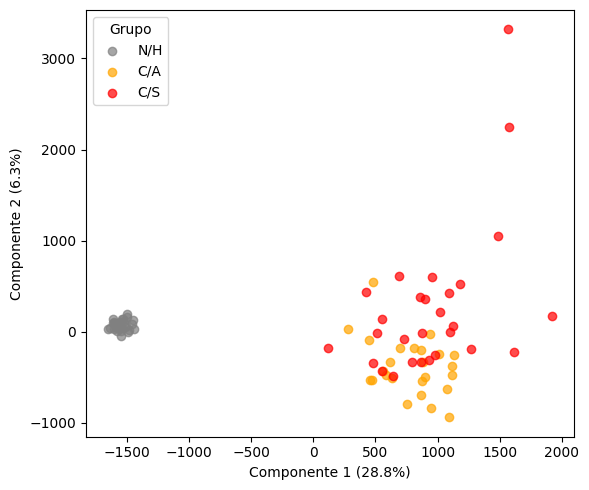

In [ ]:
# PCA para saber si los grupos se separan visualmente
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(dataset_final[proteinas])

plt.figure(figsize=(6,5))
colores = {"N/H":"gray", "C/A":"orange", "C/S":"red"}
for grupo in ["N/H", "C/A", "C/S"]:
    filtro = dataset_final["Grupo"] == grupo
    plt.scatter(componentes[filtro,0], componentes[filtro,1], label=grupo, color=colores[grupo], alpha=0.7)

plt.xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Grupo")
plt.tight_layout()
plt.savefig("figura1_pca.png", dpi=200)
plt.show()
# PCA reduce las 192 proteínas a 2 dimensiones para poder graficarlas
# cada punto es un paciente sintético, coloreado por grupo.
# los grupos difieren entre si?
# rta: los controles sanos difieren de los individuos infectados
# infectados asintomaticos vs sintomaticos no se pueden dividir

In [ ]:
documento = Document()

def agregar_titulo_apa(doc, numero, titulo_texto, tipo="Tabla"):
    p1 = doc.add_paragraph()
    r1 = p1.add_run(f"{tipo} {numero}")
    r1.bold = True
    r1.font.name = "Times New Roman"; r1.font.size = Pt(12)
    p2 = doc.add_paragraph()
    r2 = p2.add_run(titulo_texto)
    r2.italic = True
    r2.font.name = "Times New Roman"; r2.font.size = Pt(12)

def agregar_nota_apa(doc, texto_nota):
    p = doc.add_paragraph()
    r = p.add_run("Nota. " + texto_nota)
    r.italic = True
    r.font.name = "Times New Roman"; r.font.size = Pt(10)

def bordes_horizontales(fila_celdas, arriba=False, abajo=False):
    for celda in fila_celdas:
        tc_pr = celda._tc.get_or_add_tcPr()
        bordes = OxmlElement("w:tcBorders")
        for lado, activo in [("top", arriba), ("bottom", abajo)]:
            if activo:
                b = OxmlElement(f"w:{lado}")
                b.set(qn("w:val"), "single"); b.set(qn("w:sz"), "8"); b.set(qn("w:color"), "000000")
                bordes.append(b)
        tc_pr.append(bordes)

# --- Tabla 2 ---
agregar_titulo_apa(documento, 2, "Estadísticos descriptivos del dataset proteómico sintético por grupo clínico")

t = documento.add_table(rows=1, cols=len(tabla_resumen.columns))
for i, col in enumerate(tabla_resumen.columns):
    t.rows[0].cells[i].text = col
    for p in t.rows[0].cells[i].paragraphs:
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(10); r.bold=True

for _, fila in tabla_resumen.iterrows():
    celdas = t.add_row().cells
    for i, col in enumerate(tabla_resumen.columns):
        celdas[i].text = str(fila[col])
        for p in celdas[i].paragraphs:
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(9)

bordes_horizontales(t.rows[0].cells, arriba=True)
bordes_horizontales(t.rows[0].cells, abajo=True)
bordes_horizontales(t.rows[-1].cells, abajo=True)
agregar_nota_apa(documento, "DE = desvío estándar; CV = coeficiente de variación. Elaboración propia a partir de datos simulados.")

documento.add_paragraph()  # espacio

# Figura 1
agregar_titulo_apa(documento, 1, "Distribución de pacientes sintéticos según componentes principales del proteoma", tipo="Figura")
documento.add_picture("figura1_pca.png", width=Pt(300))
agregar_nota_apa(documento, "PCA = análisis de componentes principales. Elaboración propia.")

documento.save("resultados_objetivo1.docx")
print("Documento generado ✅")

Documento generado ✅


In [ ]:
files.download("resultados_objetivo1.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# fuente calibri en graficos
!apt-get install -y fonts-crosextra-carlito -q
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/crosextra/Carlito-Regular.ttf")
plt.rcParams["font.family"] = "Carlito"
print("Fuente instalada ✅")

Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-crosextra-caladea
The following NEW packages will be installed:
  fonts-crosextra-carlito
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 743 kB of archives.
After this operation, 2,798 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-crosextra-carlito all 20130920-1.1 [743 kB]
Fetched 743 kB in 1s (842 kB/s)
Selecting previously unselected package fonts-crosextra-carlito.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-crosextra-carlito_20130920-1.1_all.deb ...
Unpacking fonts-crosextra-carlito (20130920-1.1) ...
Setting up fonts-crosextra-carlito (20130920-1.1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Fuente instalada ✅


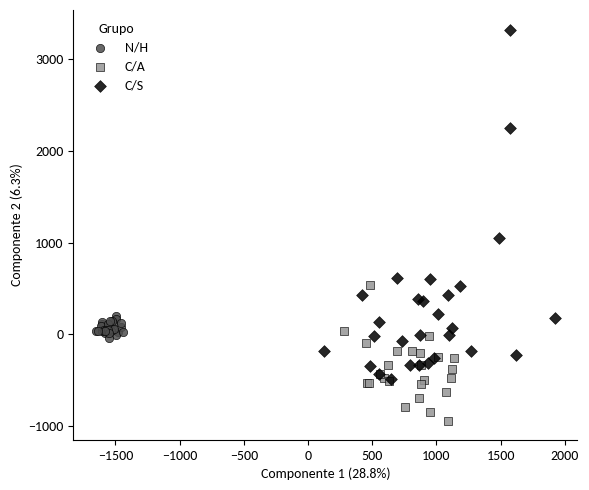

In [ ]:
# pca mas lindo
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(dataset_final[proteinas])

fig, ax = plt.subplots(figsize=(6,5))

# Escala de grises + distinto marcador por grupo (redundancia util si se imprime en B&N)
estilos = {
       "N/H": {"color": "#4d4d4d", "marker": "o"},
    "C/A": {"color": "#969696", "marker": "s"},
    "C/S": {"color": "#000000", "marker": "D"}
}

for grupo in ["N/H", "C/A", "C/S"]:
    filtro = dataset_final["Grupo"] == grupo
    ax.scatter(componentes[filtro,0], componentes[filtro,1],
               label=grupo, color=estilos[grupo]["color"],
               marker=estilos[grupo]["marker"], edgecolor="black", linewidth=0.5, alpha=0.85)

ax.set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", color="black")
ax.set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", color="black")
ax.tick_params(colors="black")
for etiqueta in ax.get_xticklabels() + ax.get_yticklabels():
    etiqueta.set_color("black")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

ax.legend(title="Grupo", frameon=False, labelcolor="black")

plt.tight_layout()
plt.savefig("figura1_pca.png", dpi=200)
plt.show()